In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
reference_img = cv2.imread("left.jpg")
scene_img = cv2.imread("right.jpg")

In [3]:
if reference_img is None or scene_img is None:
    print("Error: left.jpg or right.jpg not found")
    exit()

In [4]:
ref_gray = cv2.cvtColor(reference_img, cv2.COLOR_BGR2GRAY)
scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)

In [12]:
# ============================================================
# FEATURE DETECTION USING ORB
# ============================================================

In [13]:
orb = cv2.ORB_create(nfeatures=1000)

In [14]:
ref_kp, ref_desc = orb.detectAndCompute(ref_gray, None)
scene_kp, scene_desc = orb.detectAndCompute(scene_gray, None)

In [15]:
print("Reference Image Keypoints :", len(ref_kp))
print("Scene Image Keypoints     :", len(scene_kp))

Reference Image Keypoints : 1000
Scene Image Keypoints     : 1000


In [16]:
ref_with_kp = cv2.drawKeypoints(reference_img, ref_kp, None, color=(0, 255, 0))
scene_with_kp = cv2.drawKeypoints(scene_img, scene_kp, None, color=(0, 255, 0))

In [17]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

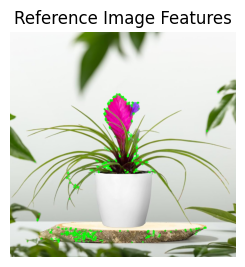

In [18]:
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(ref_with_kp, cv2.COLOR_BGR2RGB))
plt.title("Reference Image Features")
plt.axis("off")

(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

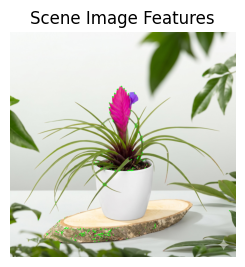

In [19]:
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(scene_with_kp, cv2.COLOR_BGR2RGB))
plt.title("Scene Image Features")
plt.axis("off")

In [20]:
# ============================================================
# FEATURE MATCHING
# ============================================================

In [21]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches = bf.knnMatch(ref_desc, scene_desc, k=2)
good_matches = []

In [22]:
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

In [23]:
print("Good Matches :", len(good_matches))

Good Matches : 22


In [24]:
match_img = cv2.drawMatches(
    reference_img,
    ref_kp,
    scene_img,
    scene_kp,
    good_matches[:50],
    None,
    flags=2
)

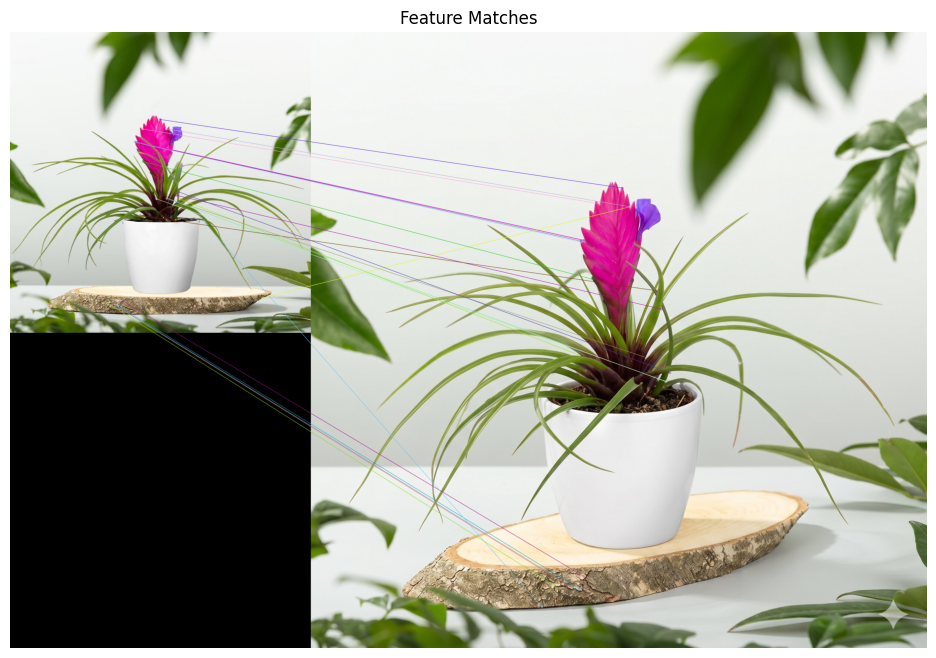

In [25]:
plt.figure(figsize=(18, 8))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matches")
plt.axis("off")
plt.show()

In [26]:
# ============================================================
# HOMOGRAPHY ESTIMATION
# ============================================================

In [27]:
if len(good_matches) < 4:
    print("Not enough matches to compute homography")
    exit()

In [28]:
src_pts = np.float32([
    ref_kp[m.queryIdx].pt for m in good_matches
]).reshape(-1, 1, 2)

In [29]:
dst_pts = np.float32([
    scene_kp[m.trainIdx].pt for m in good_matches
]).reshape(-1, 1, 2)

In [30]:
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
print("Homography Matrix:\n", H)

Homography Matrix:
 [[ 2.12420306e+00  2.02681504e-01  6.05524047e+00]
 [-1.65398427e-01  2.24938226e+00 -6.43532627e+00]
 [ 1.67938846e-04  1.13108533e-05  1.00000000e+00]]


In [31]:
h, w = reference_img.shape[:2]

corners = np.float32([
    [0, 0],
    [w, 0],
    [w, h],
    [0, h]
]).reshape(-1, 1, 2)

In [33]:
projected_corners = cv2.perspectiveTransform(corners, H)

In [34]:
scene_with_box = scene_img.copy()

In [35]:
cv2.polylines(
    scene_with_box,
    [np.int32(projected_corners)],
    True,
    (0, 255, 0),
    3
)

array([[[249, 250, 248],
        [249, 250, 248],
        [249, 250, 248],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[249, 250, 248],
        [249, 250, 248],
        [249, 250, 248],
        ...,
        [247, 247, 247],
        [248, 248, 248],
        [248, 248, 248]],

       [[249, 250, 248],
        [249, 250, 248],
        [249, 250, 248],
        ...,
        [248, 248, 248],
        [248, 248, 248],
        [248, 248, 248]],

       ...,

       [[215, 222, 217],
        [215, 222, 217],
        [216, 222, 217],
        ...,
        [188, 196, 186],
        [188, 196, 186],
        [188, 196, 186]],

       [[214, 221, 216],
        [214, 221, 216],
        [215, 221, 216],
        ...,
        [188, 196, 186],
        [188, 196, 186],
        [188, 196, 186]],

       [[213, 220, 215],
        [213, 220, 215],
        [214, 220, 215],
        ...,
        [188, 196, 186],
        [188, 196, 186],
        [188, 196, 186]]

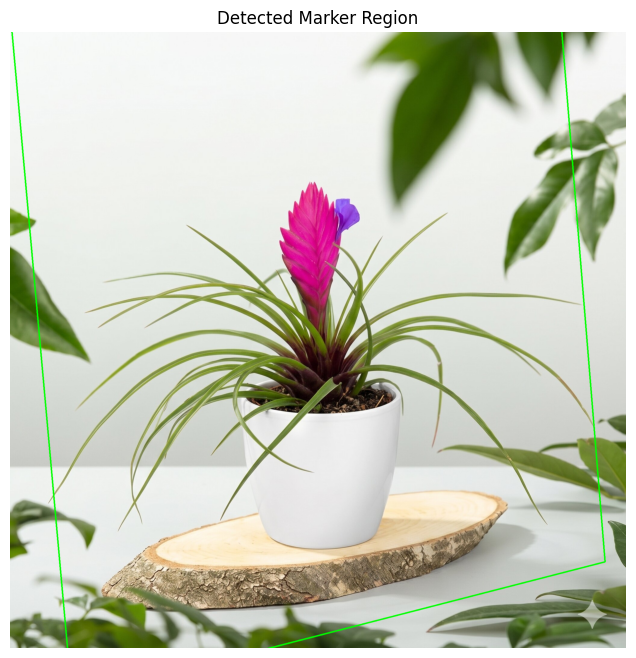

In [36]:
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(scene_with_box, cv2.COLOR_BGR2RGB))
plt.title("Detected Marker Region")
plt.axis("off")
plt.show()

In [37]:
# ============================================================
# PROJECT AND DRAW A 3D CUBE
# ============================================================

In [38]:
cube_size = min(w, h) // 2

cube_points_3d = np.float32([
    [0, 0],
    [cube_size, 0],
    [cube_size, cube_size],
    [0, cube_size],
    [0, -cube_size],
    [cube_size, -cube_size],
    [cube_size, cube_size - cube_size],
    [0, cube_size - cube_size]
]).reshape(-1, 1, 2)

In [39]:
cube_points_2d = cv2.perspectiveTransform(cube_points_3d, H)
cube_points_2d = np.int32(cube_points_2d).reshape(-1, 2)

In [41]:
result = scene_img.copy()

In [45]:
cv2.drawContours(result, [cube_points_2d[:4]], -1, (255, 0, 255), 3)
cv2.drawContours(result, [cube_points_2d[4:]], -1, (255, 0, 255), 3)

array([[[249, 250, 248],
        [249, 250, 248],
        [249, 250, 248],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[249, 250, 248],
        [249, 250, 248],
        [249, 250, 248],
        ...,
        [247, 247, 247],
        [248, 248, 248],
        [248, 248, 248]],

       [[249, 250, 248],
        [249, 250, 248],
        [249, 250, 248],
        ...,
        [248, 248, 248],
        [248, 248, 248],
        [248, 248, 248]],

       ...,

       [[215, 222, 217],
        [215, 222, 217],
        [216, 222, 217],
        ...,
        [188, 196, 186],
        [188, 196, 186],
        [188, 196, 186]],

       [[214, 221, 216],
        [214, 221, 216],
        [215, 221, 216],
        ...,
        [188, 196, 186],
        [188, 196, 186],
        [188, 196, 186]],

       [[213, 220, 215],
        [213, 220, 215],
        [214, 220, 215],
        ...,
        [188, 196, 186],
        [188, 196, 186],
        [188, 196, 186]]

In [46]:
for i in range(4):
    cv2.line(
        result,
        tuple(cube_points_2d[i]),
        tuple(cube_points_2d[i + 4]),
        (255, 0, 255),
        3
    )

In [47]:
for point in cube_points_2d:
    cv2.circle(result, tuple(point), 5, (0, 255, 255), -1)

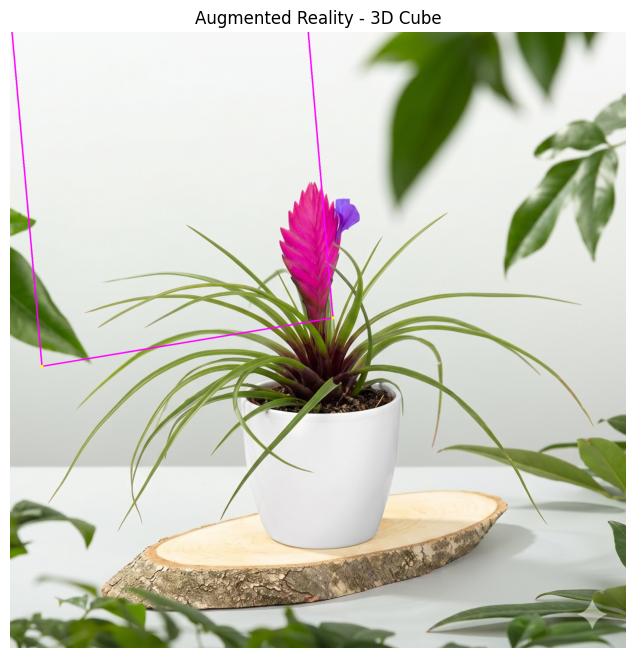

In [48]:
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Augmented Reality - 3D Cube")
plt.axis("off")
plt.show()